<a href="https://colab.research.google.com/github/DanielRegaladoUMiami/counterflow-nn/blob/main/notebooks/02_visualization_and_theory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CFNN Phase 3 — Visualization & Theory

Publication-quality visualizations and mathematical foundations:
1. **McCabe-Thiele Neural Plots** — the signature CFNN diagram
2. **Concentration Profiles** — feature norms through the tower
3. **Transfer Heatmaps** — per-dimension exchange patterns
4. **Diagnostic Dashboards** — 6-panel analysis for CFNN-A and CFNN-D
5. **Column Schematics** — visual tower representations
6. **Mathematical Foundations** — from ChemE to neural networks

**Author:** Daniel Regalado Cardoso | University of Miami

## 1. Setup

In [1]:
!git clone -b main https://github.com/DanielRegaladoUMiami/counterflow-nn.git
%cd counterflow-nn
!pip install scikit-learn matplotlib pandas pytest torchvision -q

Cloning into 'counterflow-nn'...
remote: Enumerating objects: 90, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (68/68), done.
remote: Total 90 (delta 36), reused 66 (delta 19), pack-reused 0 (from 0)
Receiving objects: 100% (90/90), 1.41 MiB | 11.50 MiB/s, done.
Resolving deltas: 100% (36/36), done.
/content/counterflow-nn


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

from src.network import CounterFlowNetwork
from src.distillation import DistillationNetwork
from src.utils import load_synthetic_dataset, prepare_data, train_model
from src.visualization import (
    mccabe_thiele_plot, concentration_profile, driving_force_profile,
    transfer_heatmap, diagnostic_dashboard, column_schematic,
)
from src.diagnostics import print_diagnostics

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {device}')

PyTorch 2.10.0+cu128 | Device: cuda


## 2. Train Models for Visualization

In [3]:
# Load moons dataset
X, y = load_synthetic_dataset('moons', n_samples=1000, noise=0.2, seed=42)
train_ld, test_ld, d_in, n_cls = prepare_data(X, y, seed=42)
X_scaled = torch.FloatTensor(StandardScaler().fit_transform(X))

# Train CFNN-A (8 plates for rich visualization)
model_a = CounterFlowNetwork(
    d_in=d_in, d_gas=32, d_liquid=32,
    n_plates=8, d_out=n_cls, n_sweeps=2
)
train_model(model_a, train_ld, test_ld, n_epochs=150, device=device, verbose=True, print_every=50)
model_a.to('cpu')

# Train CFNN-D (4+4 for comparison)
model_d = DistillationNetwork(
    d_in=d_in, d_gas=32, d_liquid=32,
    n_plates_rect=4, n_plates_strip=4,
    d_out=n_cls, n_sweeps=2,
    reflux_ratio=0.3, reboil_ratio=0.2,
)
train_model(model_d, train_ld, test_ld, n_epochs=150, device=device, verbose=True, print_every=50)
model_d.to('cpu')

print(f'CFNN-A params: {model_a.count_parameters()}')
print(f'CFNN-D params: {model_d.count_parameters()}')

Epoch   50 | Train: 0.0807 | Test: 0.0336 | accuracy: 0.9900
Epoch  100 | Train: 0.0656 | Test: 0.0241 | accuracy: 0.9900
Epoch  150 | Train: 0.0606 | Test: 0.0218 | accuracy: 0.9900
Epoch   50 | Train: 0.0806 | Test: 0.0282 | accuracy: 0.9900
Epoch  100 | Train: 0.0631 | Test: 0.0285 | accuracy: 0.9900
Epoch  150 | Train: 0.0683 | Test: 0.0233 | accuracy: 0.9900
CFNN-A params: 4386
CFNN-D params: 10853


## 3. McCabe-Thiele Neural Plots

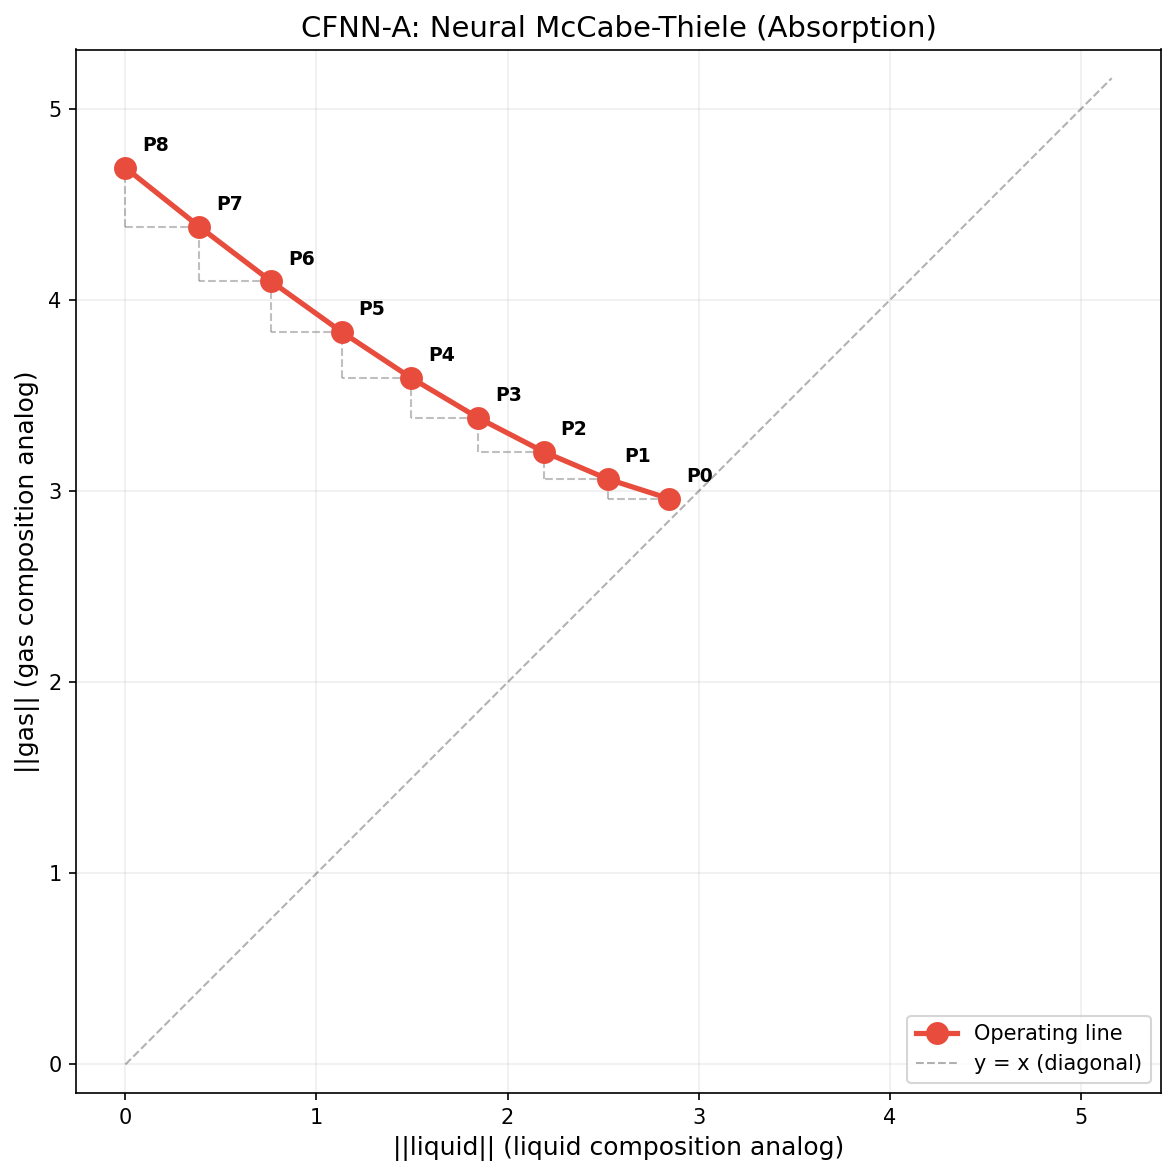

In [4]:
# CFNN-A McCabe-Thiele
fig = mccabe_thiele_plot(
    model_a, X_scaled,
    title='CFNN-A: Neural McCabe-Thiele (Absorption)',
    show_steps=True,
    figsize=(8, 8),
)
plt.show()

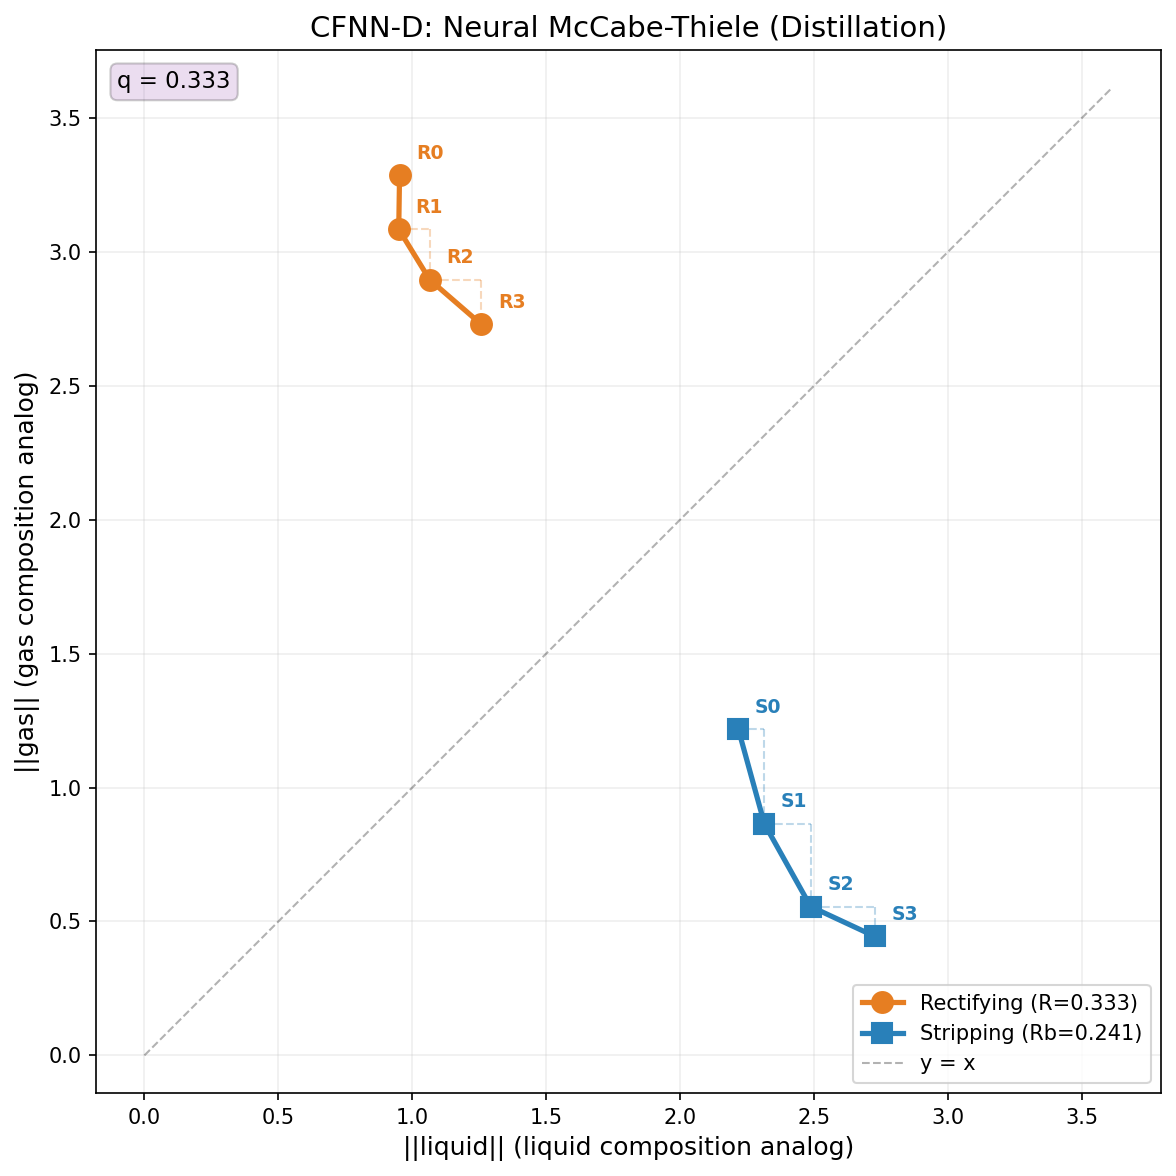

In [5]:
# CFNN-D McCabe-Thiele (shows separate rectifying and stripping lines)
fig = mccabe_thiele_plot(
    model_d, X_scaled,
    title='CFNN-D: Neural McCabe-Thiele (Distillation)',
    show_steps=True,
    figsize=(8, 8),
)
plt.show()

## 4. Concentration Profiles

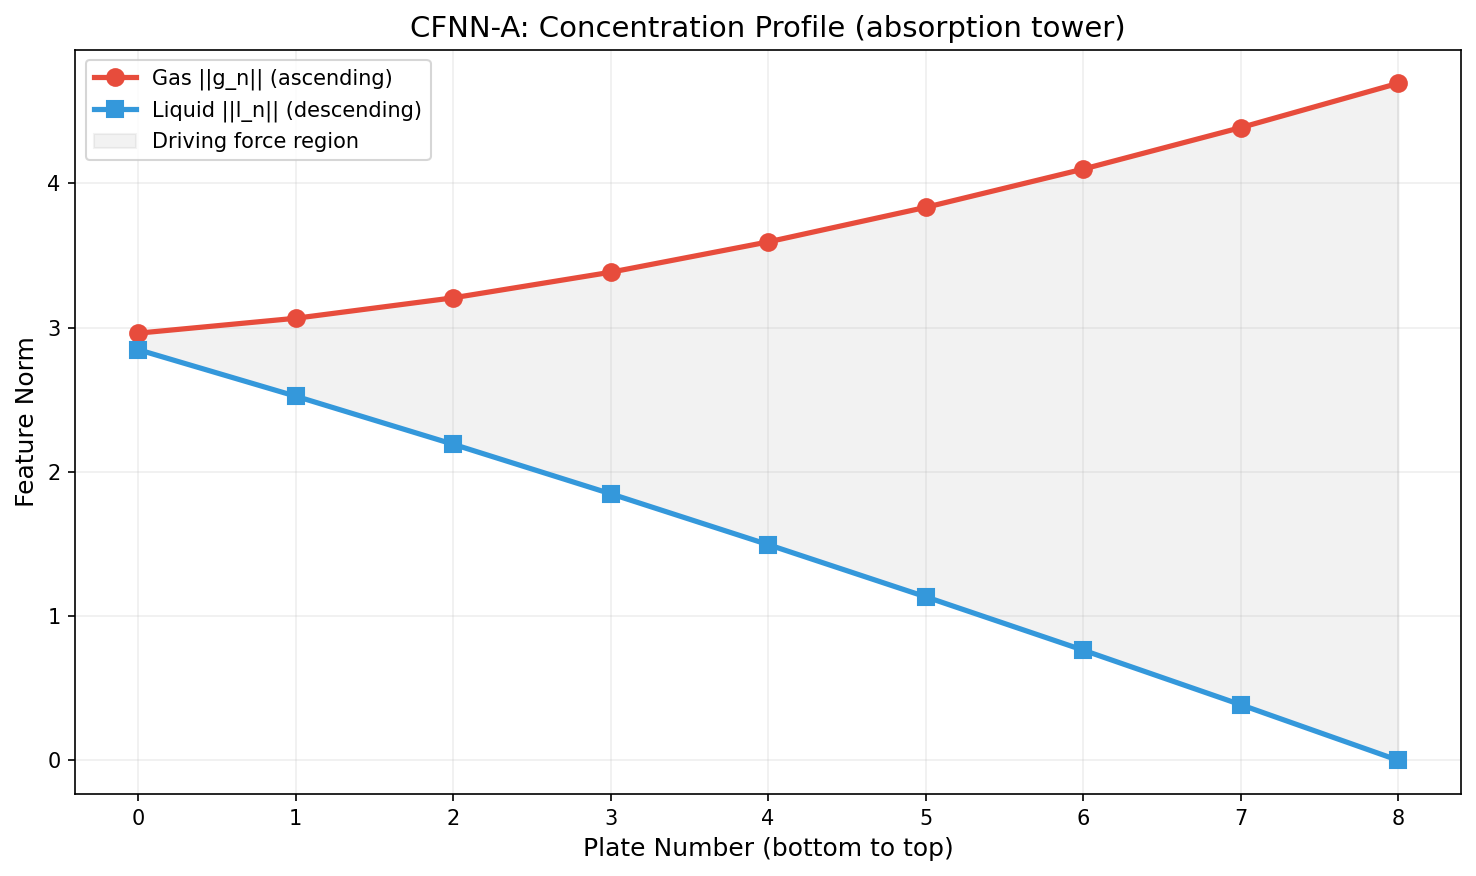

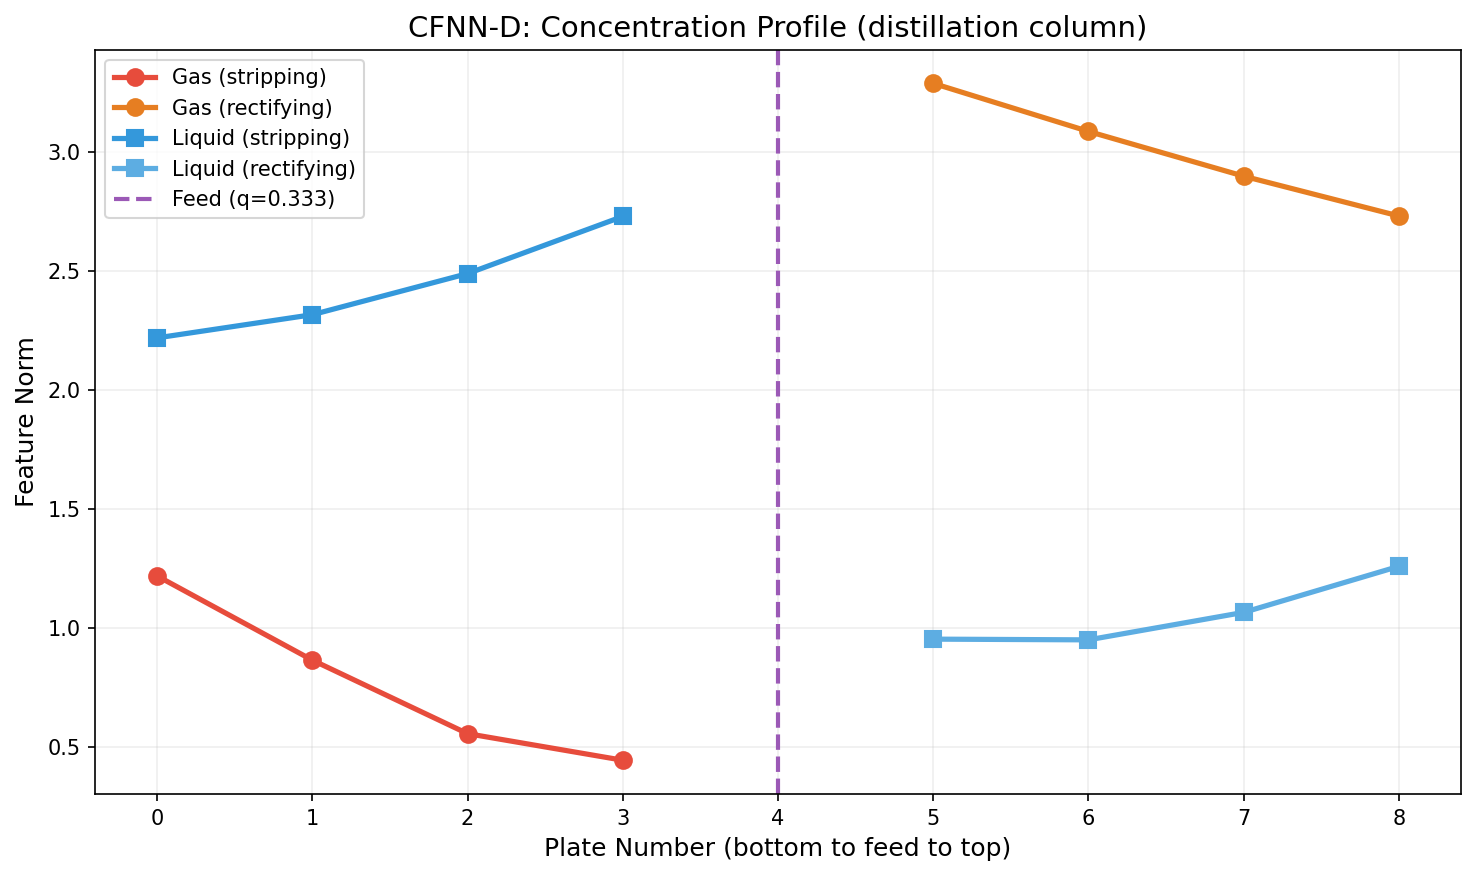

In [6]:
# Side by side concentration profiles
fig = concentration_profile(
    model_a, X_scaled,
    title='CFNN-A: Concentration Profile (absorption tower)',
)
plt.show()

fig = concentration_profile(
    model_d, X_scaled,
    title='CFNN-D: Concentration Profile (distillation column)',
)
plt.show()

## 5. Driving Force & Transfer Profiles

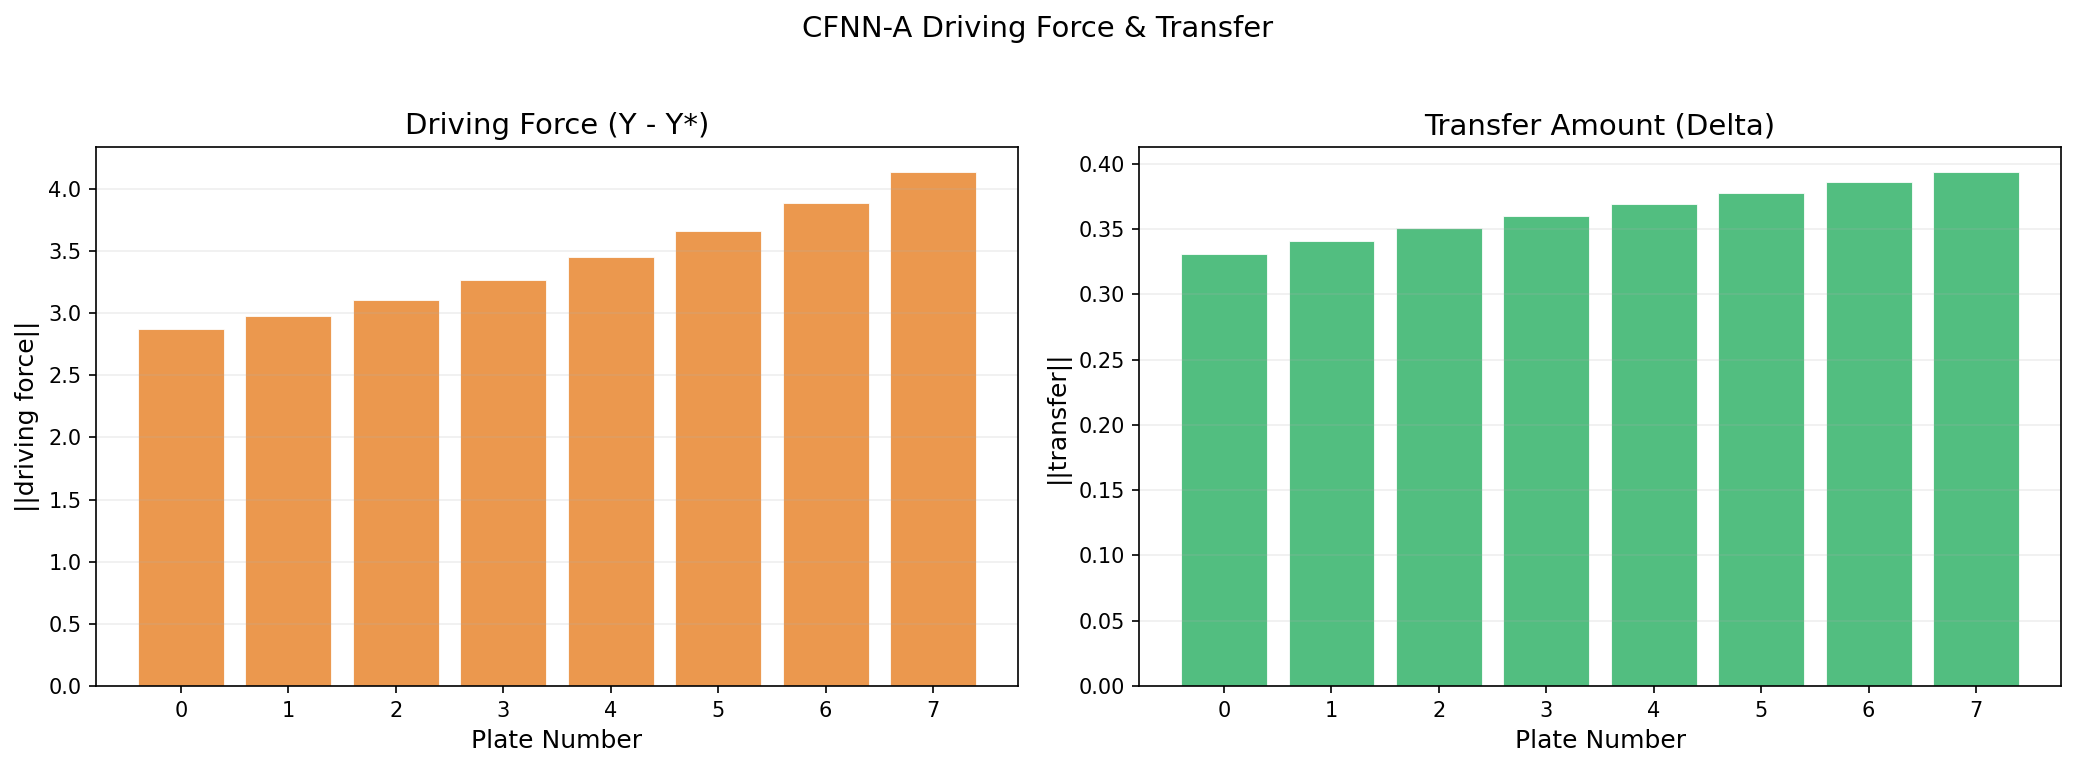

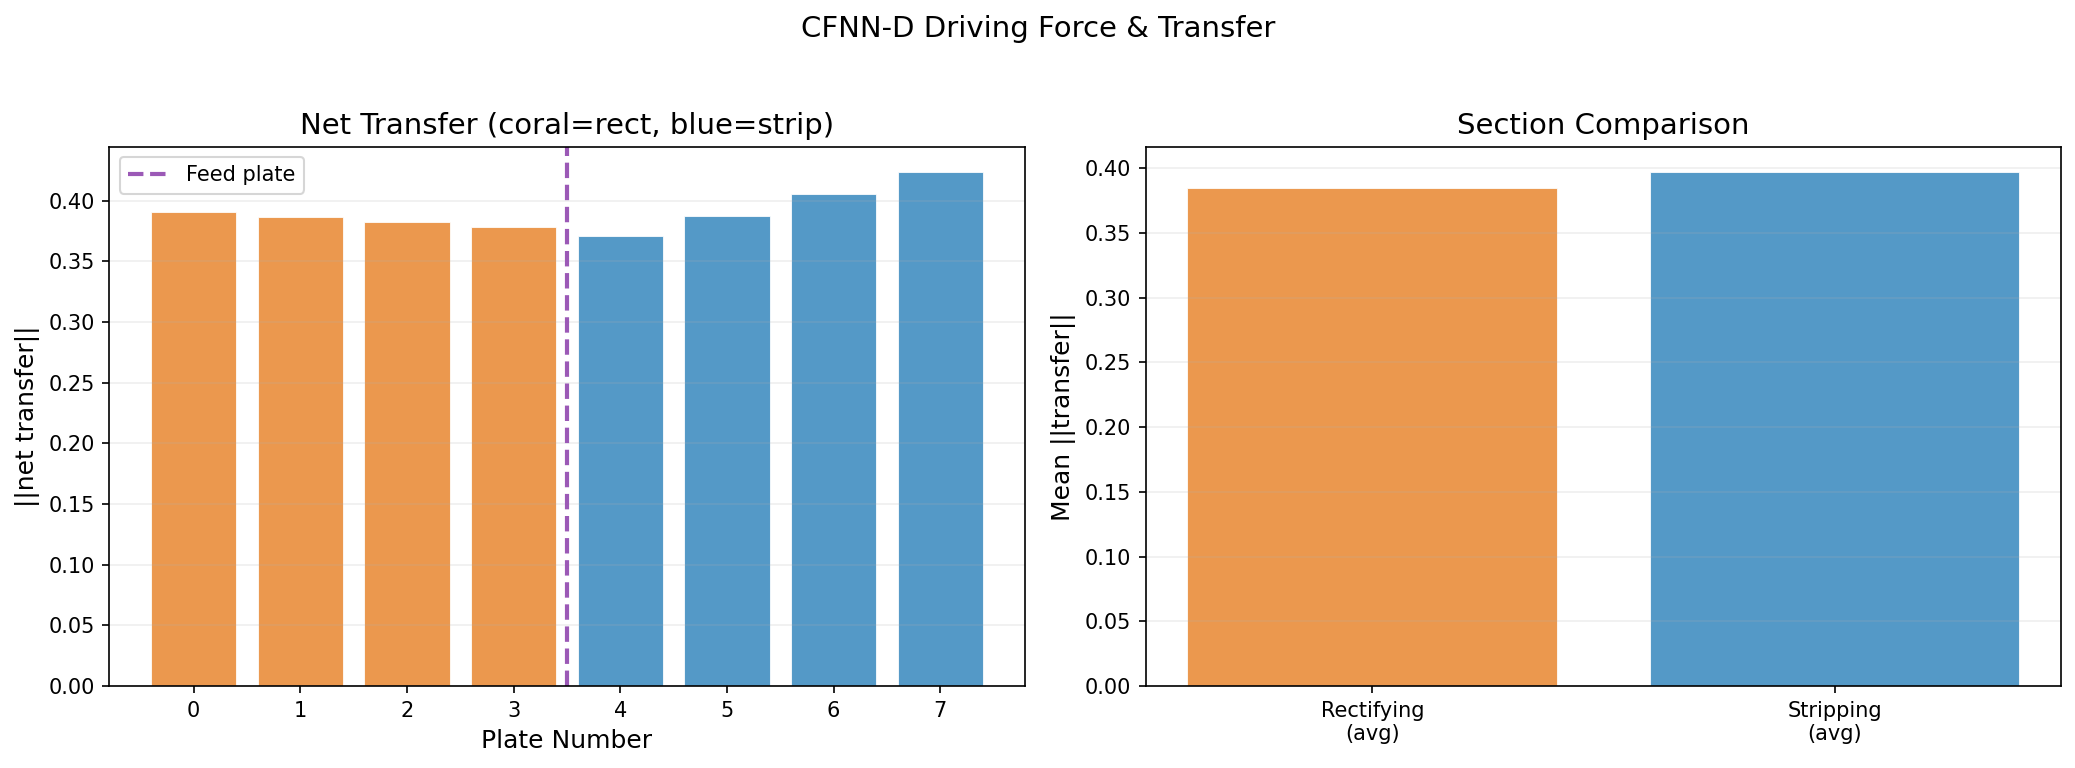

In [7]:
fig = driving_force_profile(model_a, X_scaled, title='CFNN-A Driving Force & Transfer')
plt.show()

fig = driving_force_profile(model_d, X_scaled, title='CFNN-D Driving Force & Transfer')
plt.show()

## 6. Transfer Heatmaps

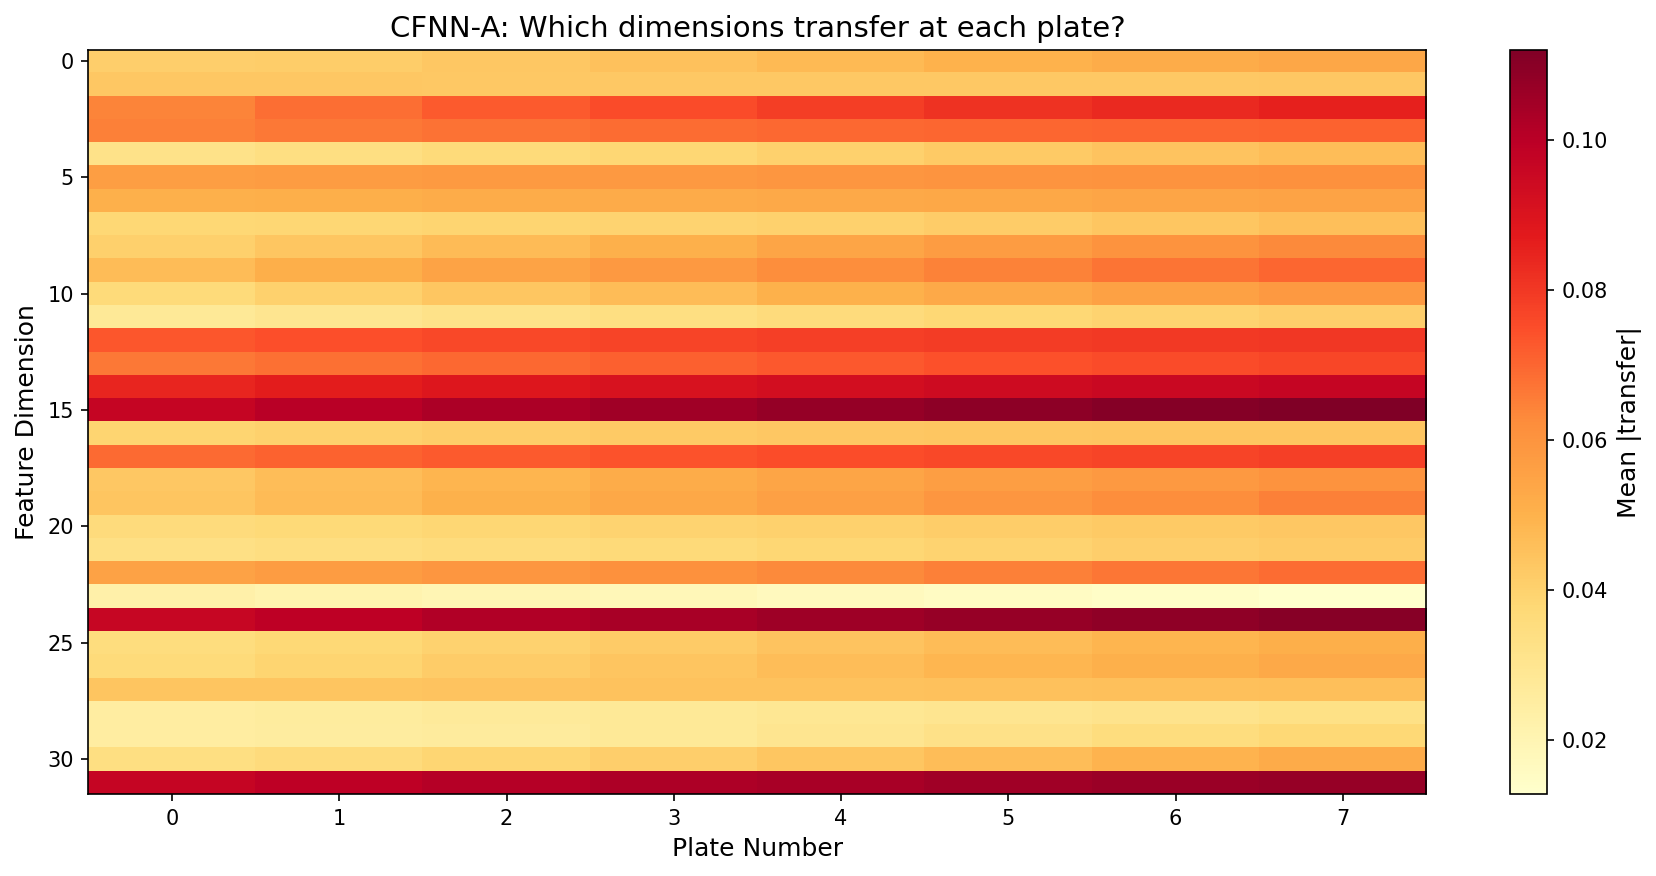

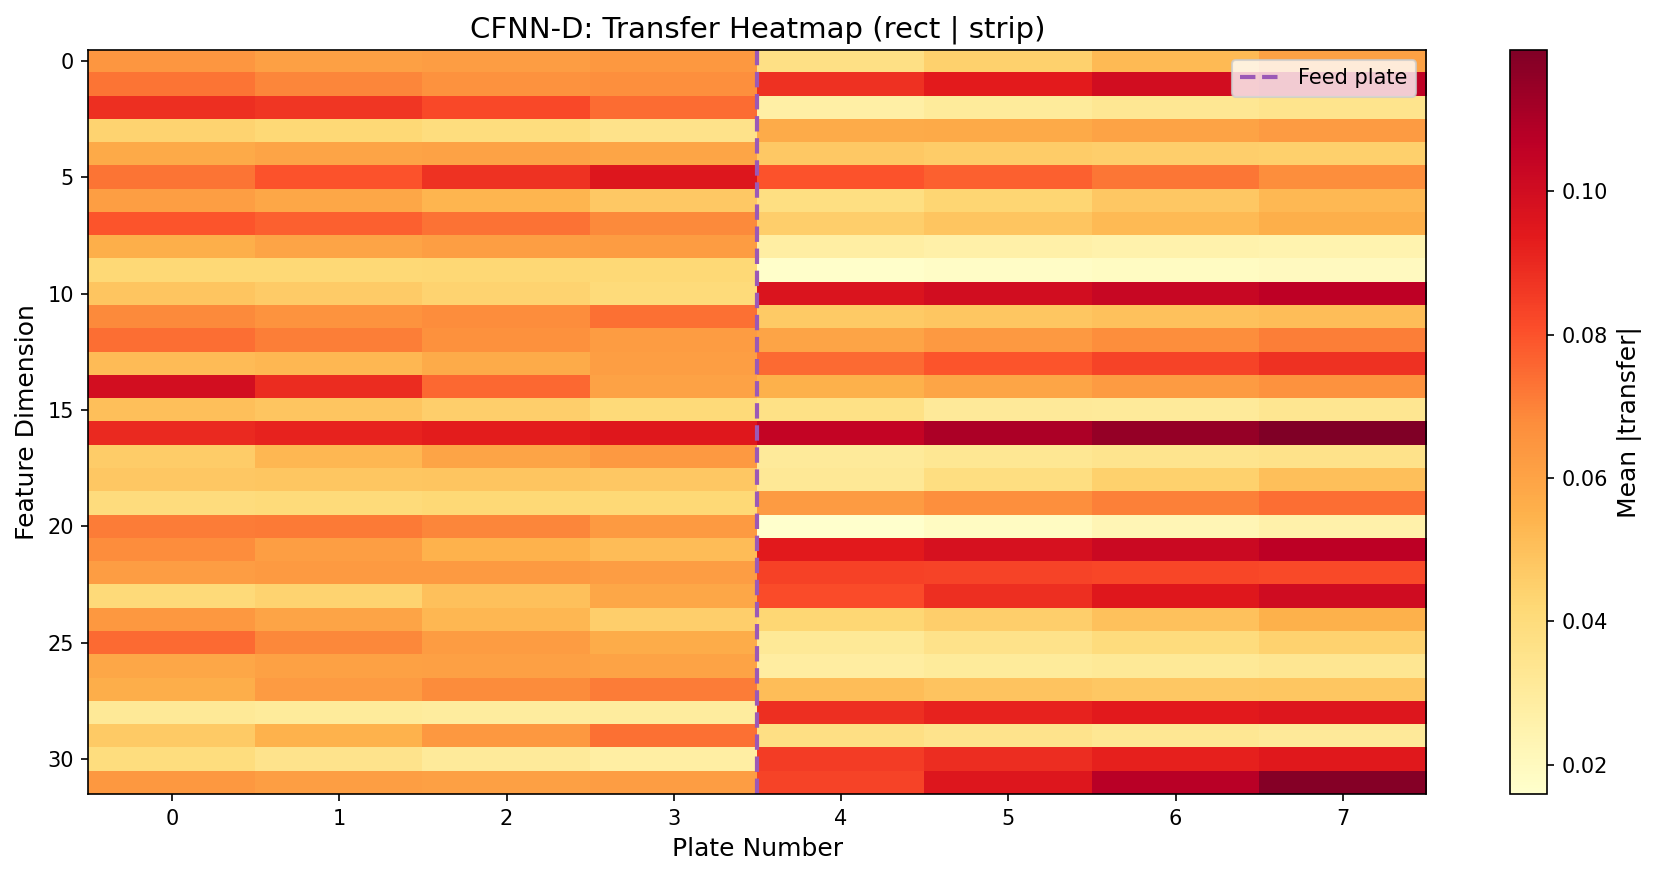

In [8]:
fig = transfer_heatmap(model_a, X_scaled, title='CFNN-A: Which dimensions transfer at each plate?')
plt.show()

fig = transfer_heatmap(model_d, X_scaled, title='CFNN-D: Transfer Heatmap (rect | strip)')
plt.show()

## 7. Full Diagnostic Dashboards

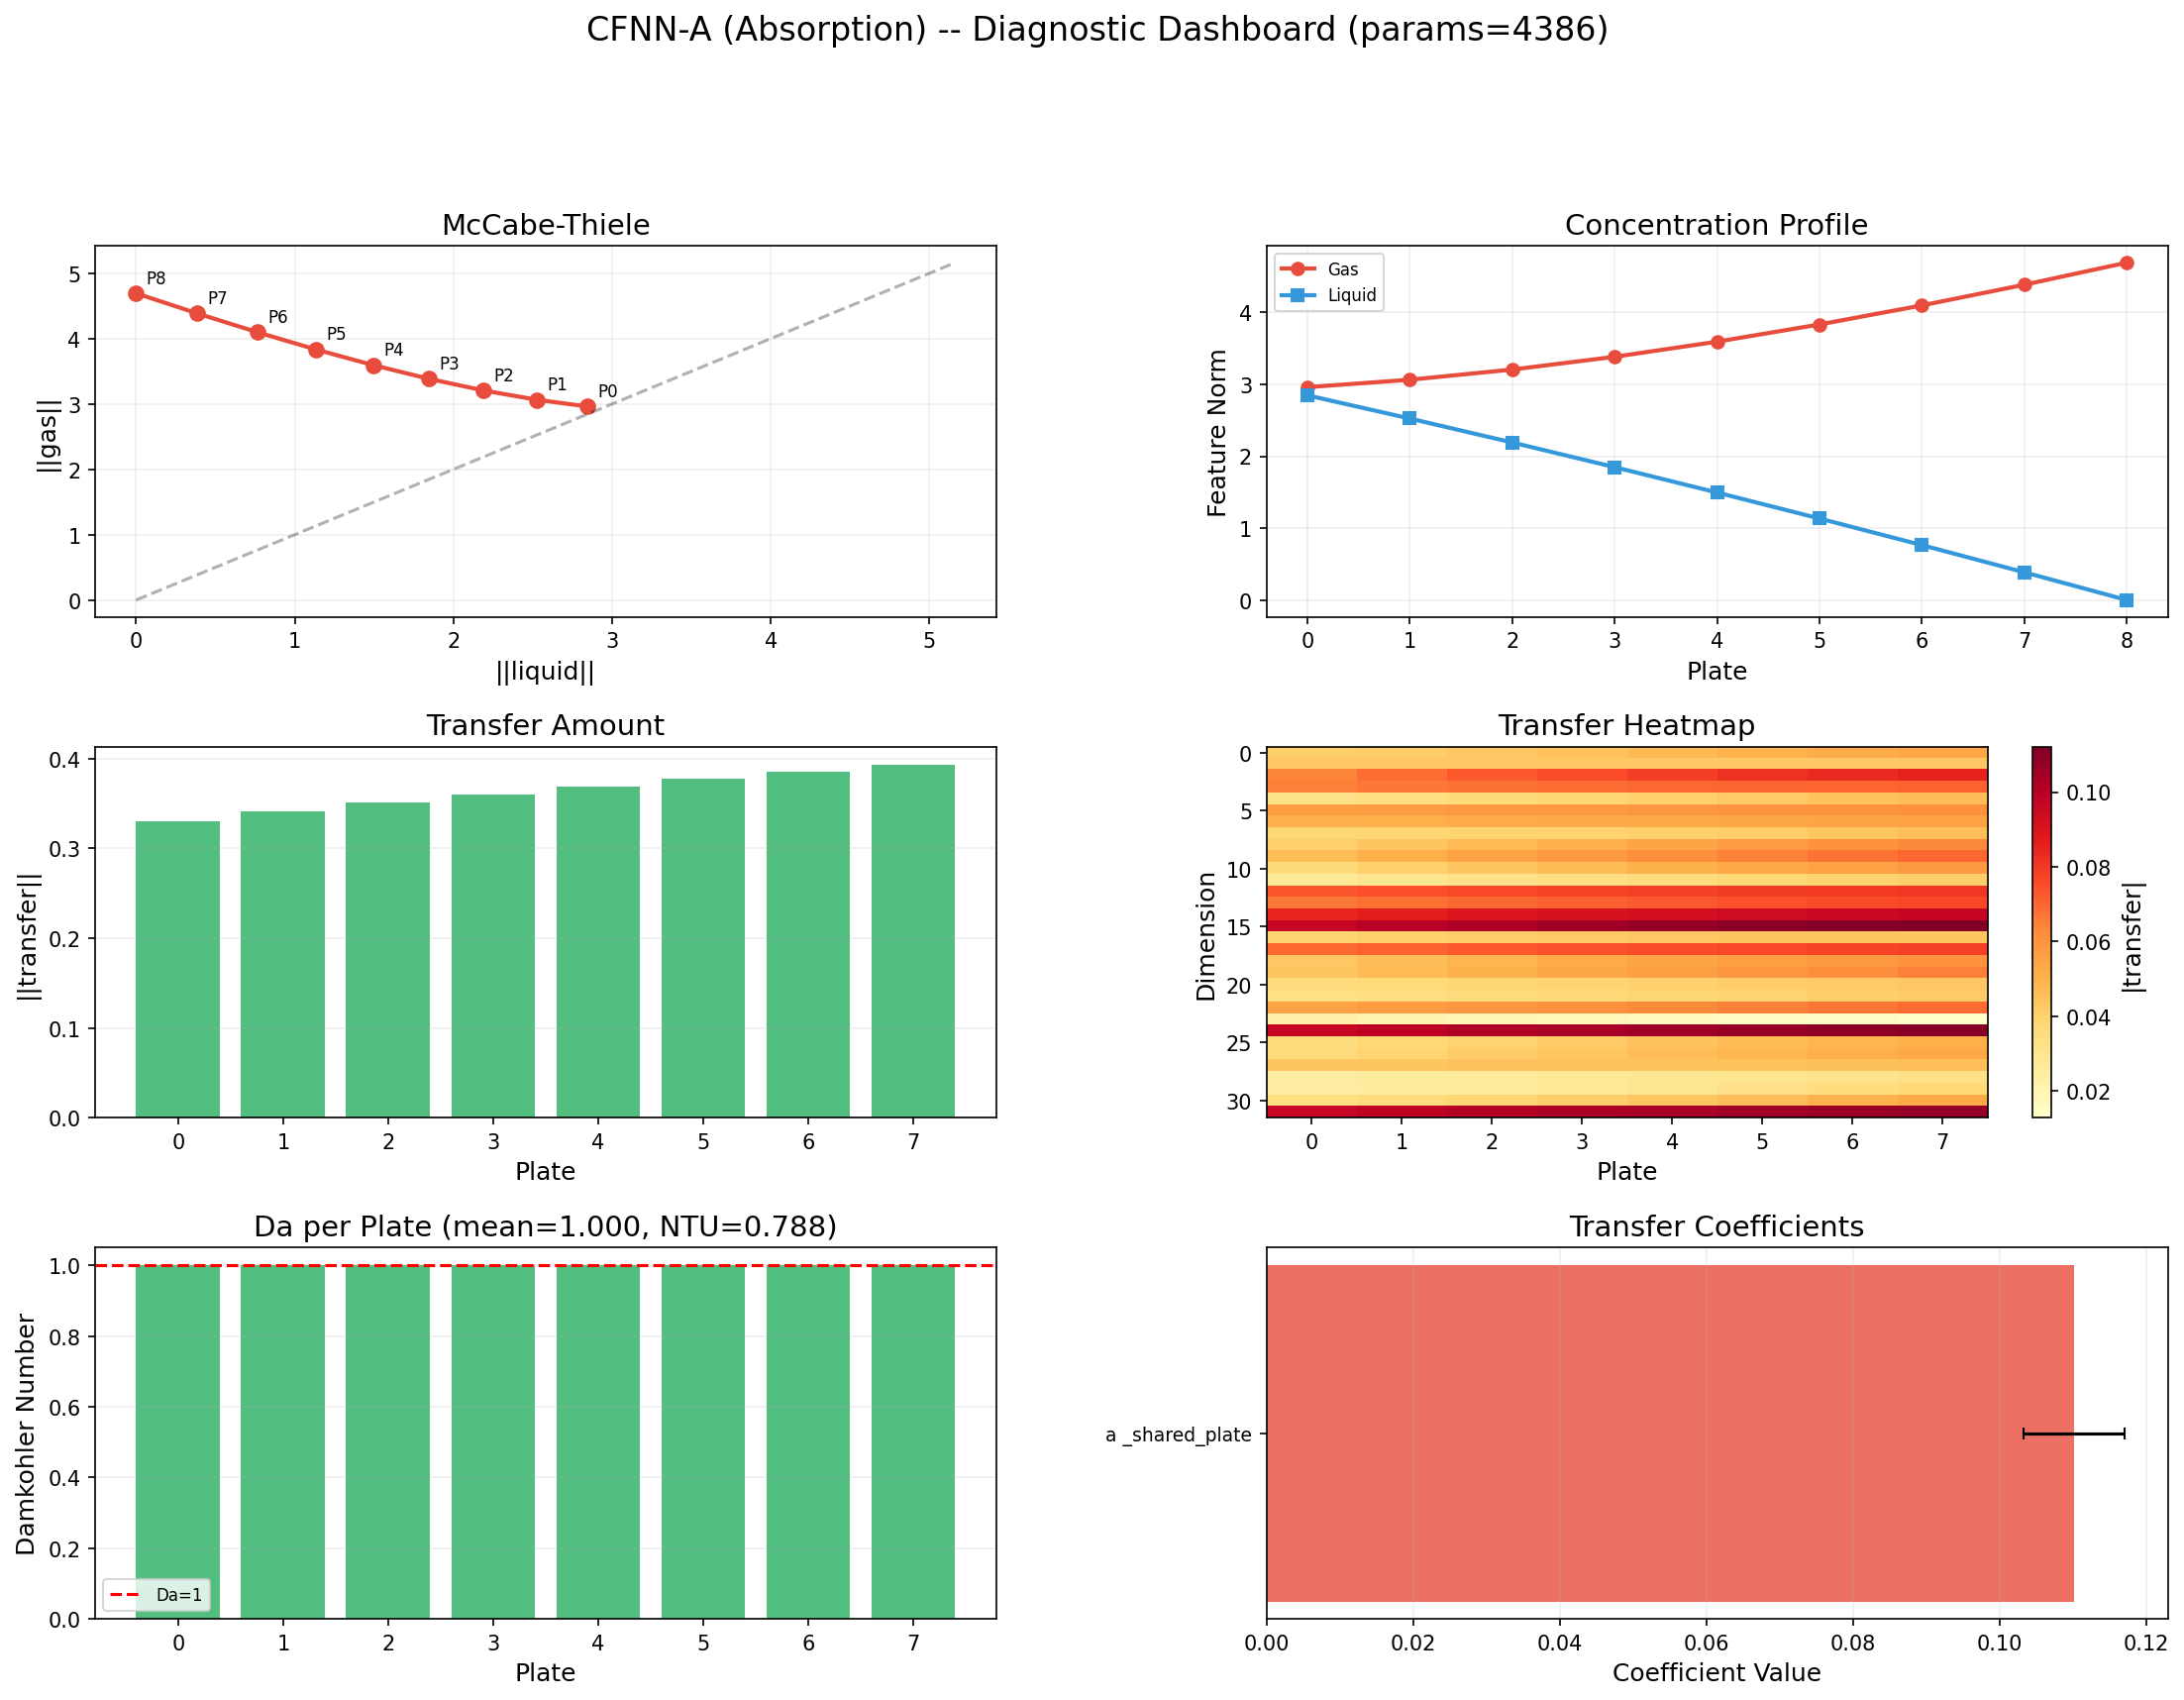

In [9]:
# CFNN-A Dashboard
fig = diagnostic_dashboard(model_a, X_scaled, model_name='CFNN-A (Absorption)')
plt.show()

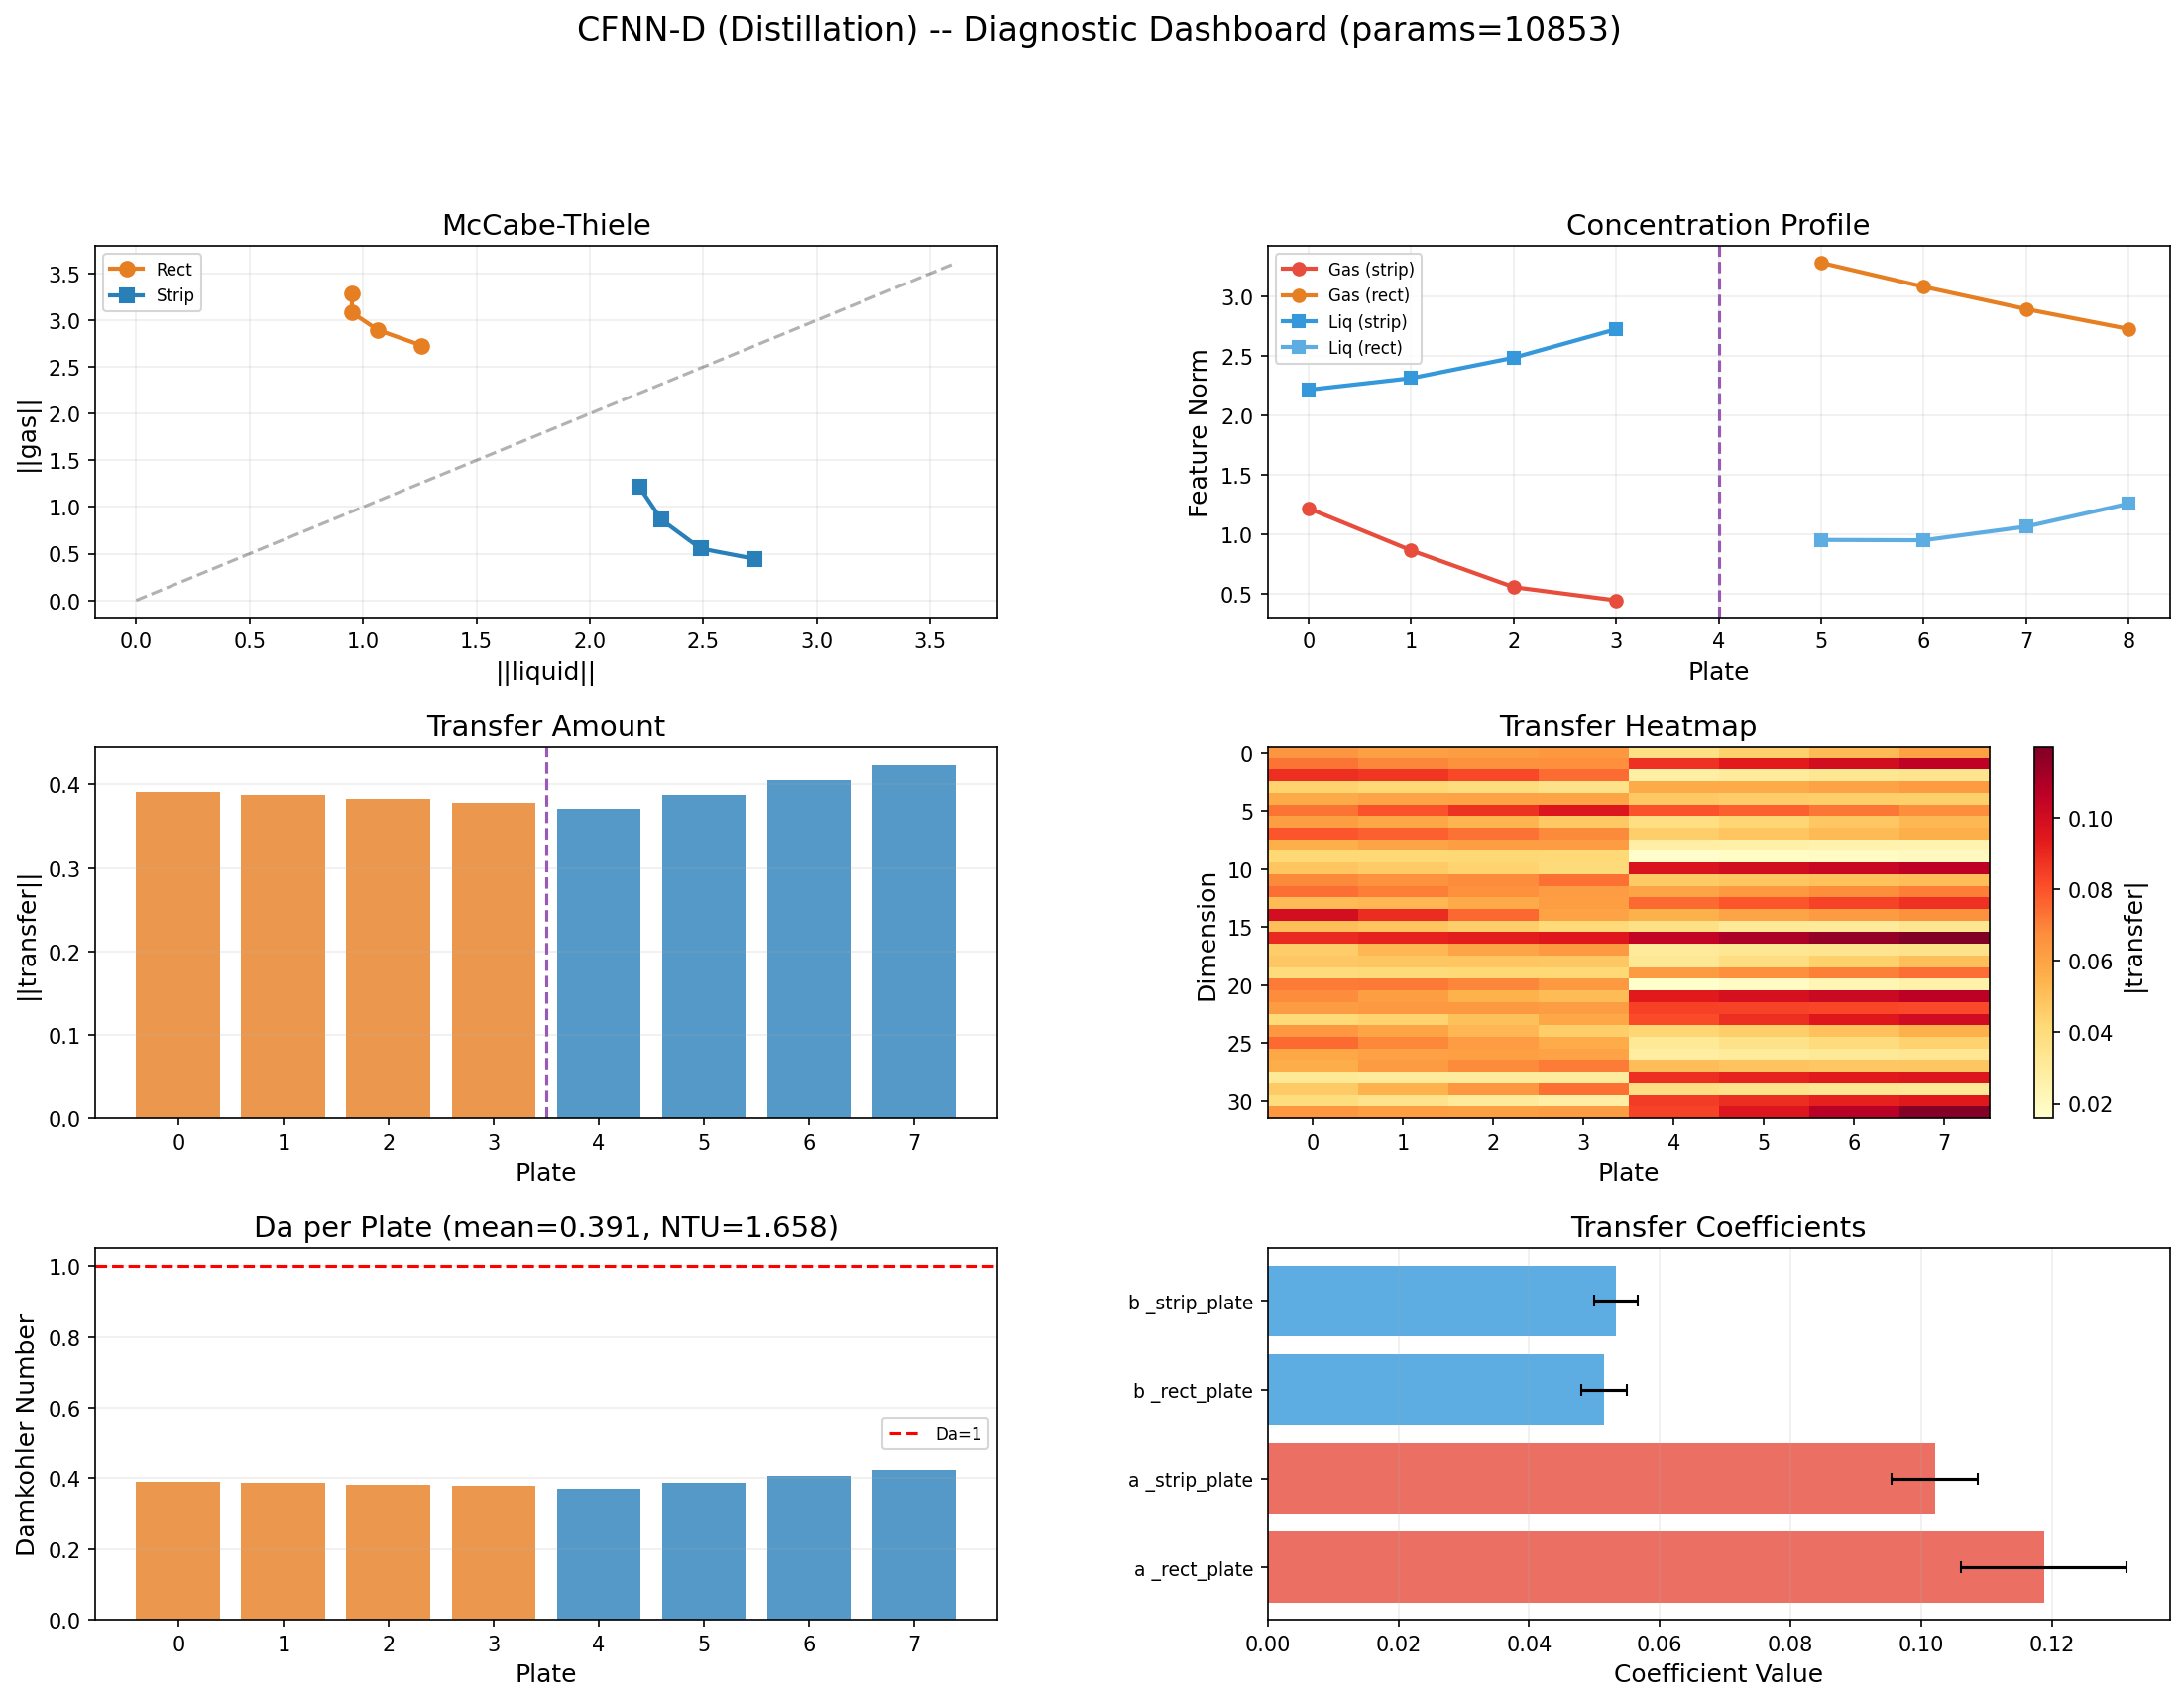

In [10]:
# CFNN-D Dashboard
fig = diagnostic_dashboard(model_d, X_scaled, model_name='CFNN-D (Distillation)')
plt.show()

## 8. Column Schematics

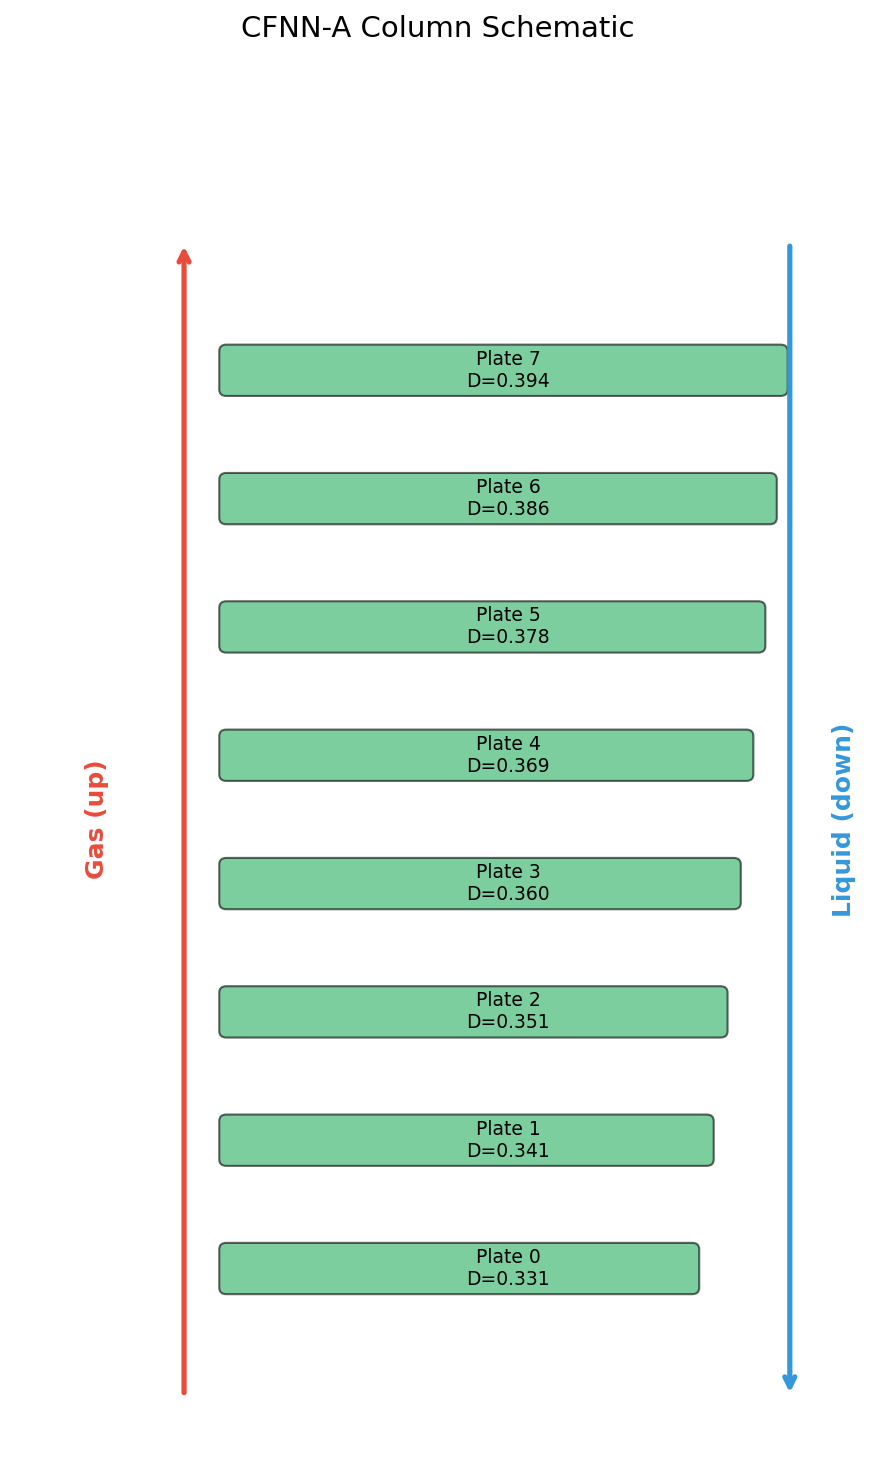

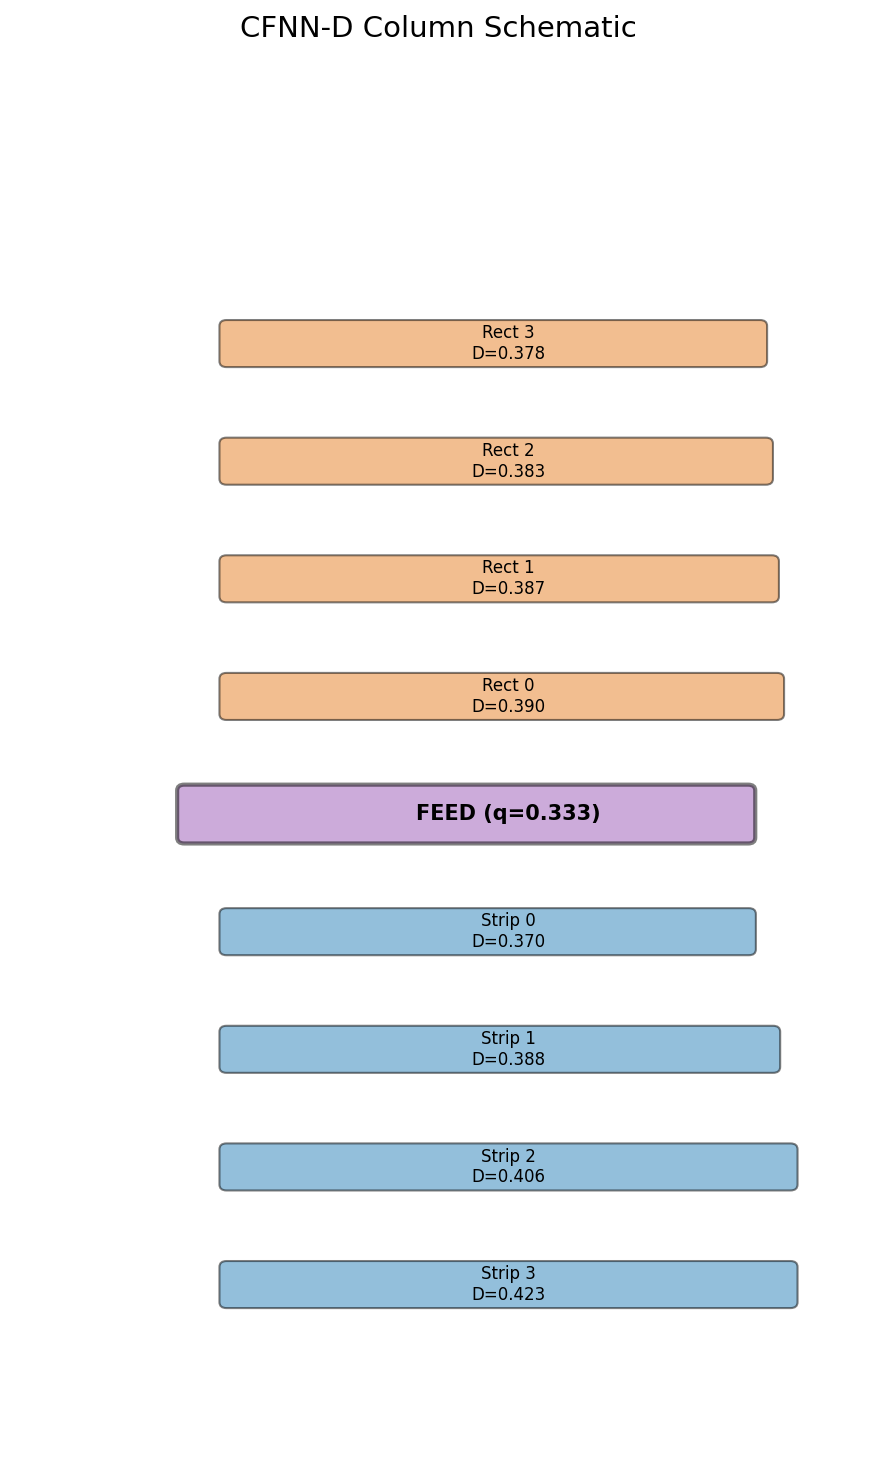

In [11]:
fig = column_schematic(model_a, X_scaled, title='CFNN-A Column Schematic')
plt.show()

fig = column_schematic(model_d, X_scaled, title='CFNN-D Column Schematic')
plt.show()

## 9. Mathematical Foundations

### 9.1 From Mass Transfer to Neural Networks

In a packed absorption tower, the gas-phase mass balance is:

$$G_s \frac{dY}{dZ} = K_Y a (Y - Y^*)$$

where $Y$ is the gas mole ratio, $Y^* = f(X)$ is the equilibrium value, and $K_Y a$ is the overall mass transfer coefficient.

**CFNN translates this to:**

$$\delta_n = g_n - E(l_n) \quad \text{(driving force, analog of } Y - Y^* \text{)}$$

$$\Delta_n = \alpha \cdot \tanh(T(\delta_n)) \quad \text{(transfer, analog of } K_Y a \cdot (Y - Y^*) \cdot \Delta Z \text{)}$$

$$g_{n+1} = g_n - \Delta_n, \quad l_n = l_{n+1} + \Delta_n \quad \text{(conservation)}$$

### 9.2 Conservation Law

The fundamental constraint:

$$\Delta g = -\Delta l$$

This is a **hard constraint**, not a soft regularization. What the gas stream loses at each plate, the liquid stream gains. This is equivalent to conservation of mass in a real absorption tower.

### 9.3 Equilibrium Function

The learned equilibrium $E(l) = \sigma(Wl + b)$ maps the liquid state to the "expected" gas state. In ChemE terms, this is the VLE (vapor-liquid equilibrium) curve $Y^* = f(X)$.

The sigmoid ensures $E(l) \in (0, 1)$, bounding the equilibrium estimate. This is analogous to physical systems where compositions are bounded between 0 and 1.

### 9.4 Approach C: Unrolled Bidirectional

Real absorption towers have a chicken-and-egg problem: to compute liquid at plate $n$, you need gas at plate $n-1$, but gas depends on liquid from above.

**Approach C** resolves this by alternating sweeps:
1. **Sweep down**: liquid descends using current gas estimates
2. **Sweep up**: gas ascends using freshly computed liquid values
3. Repeat for $S$ sweeps (typically $S = 2$)

This is analogous to iterative tray-by-tray calculations until convergence.

### 9.5 CFNN-D: Distillation Extension

Distillation adds:
- **Bidirectional transfer**: both $\alpha$ (condensation, gas$\to$liquid) and $\beta$ (vaporization, liquid$\to$gas)
- **Feed plate**: input enters at a specific location, splitting the column into rectifying (above) and stripping (below) sections
- **q-line**: learned feed condition $q \in (0,1)$ determines the gas/liquid split of the feed
- **Reflux**: fraction $R$ of top product recycled as liquid (condenser)
- **Reboil**: fraction of bottom product recycled as gas (reboiler)

The McCabe-Thiele diagram shows two operating lines (rectifying and stripping) with different slopes, intersecting at the feed plate.

### 9.6 Diagnostic Metrics

| Metric | ChemE Meaning | CFNN Analog |
|--------|--------------|-------------|
| **Damkohler number** (Da) | Reaction rate / flow rate | Transfer rate / information flow rate |
| **Murphree efficiency** ($\eta$) | Actual change / equilibrium change | How close each plate gets to equilibrium |
| **NTU** | $\int dY/(Y-Y^*)$ | Effective network depth |
| **Reflux ratio** (R) | L/D at condenser | Fraction of top output recycled |
| **Feed condition** (q) | Liquid fraction of feed | Learned gas/liquid split of input |

## 10. Comparison: Multiple Datasets

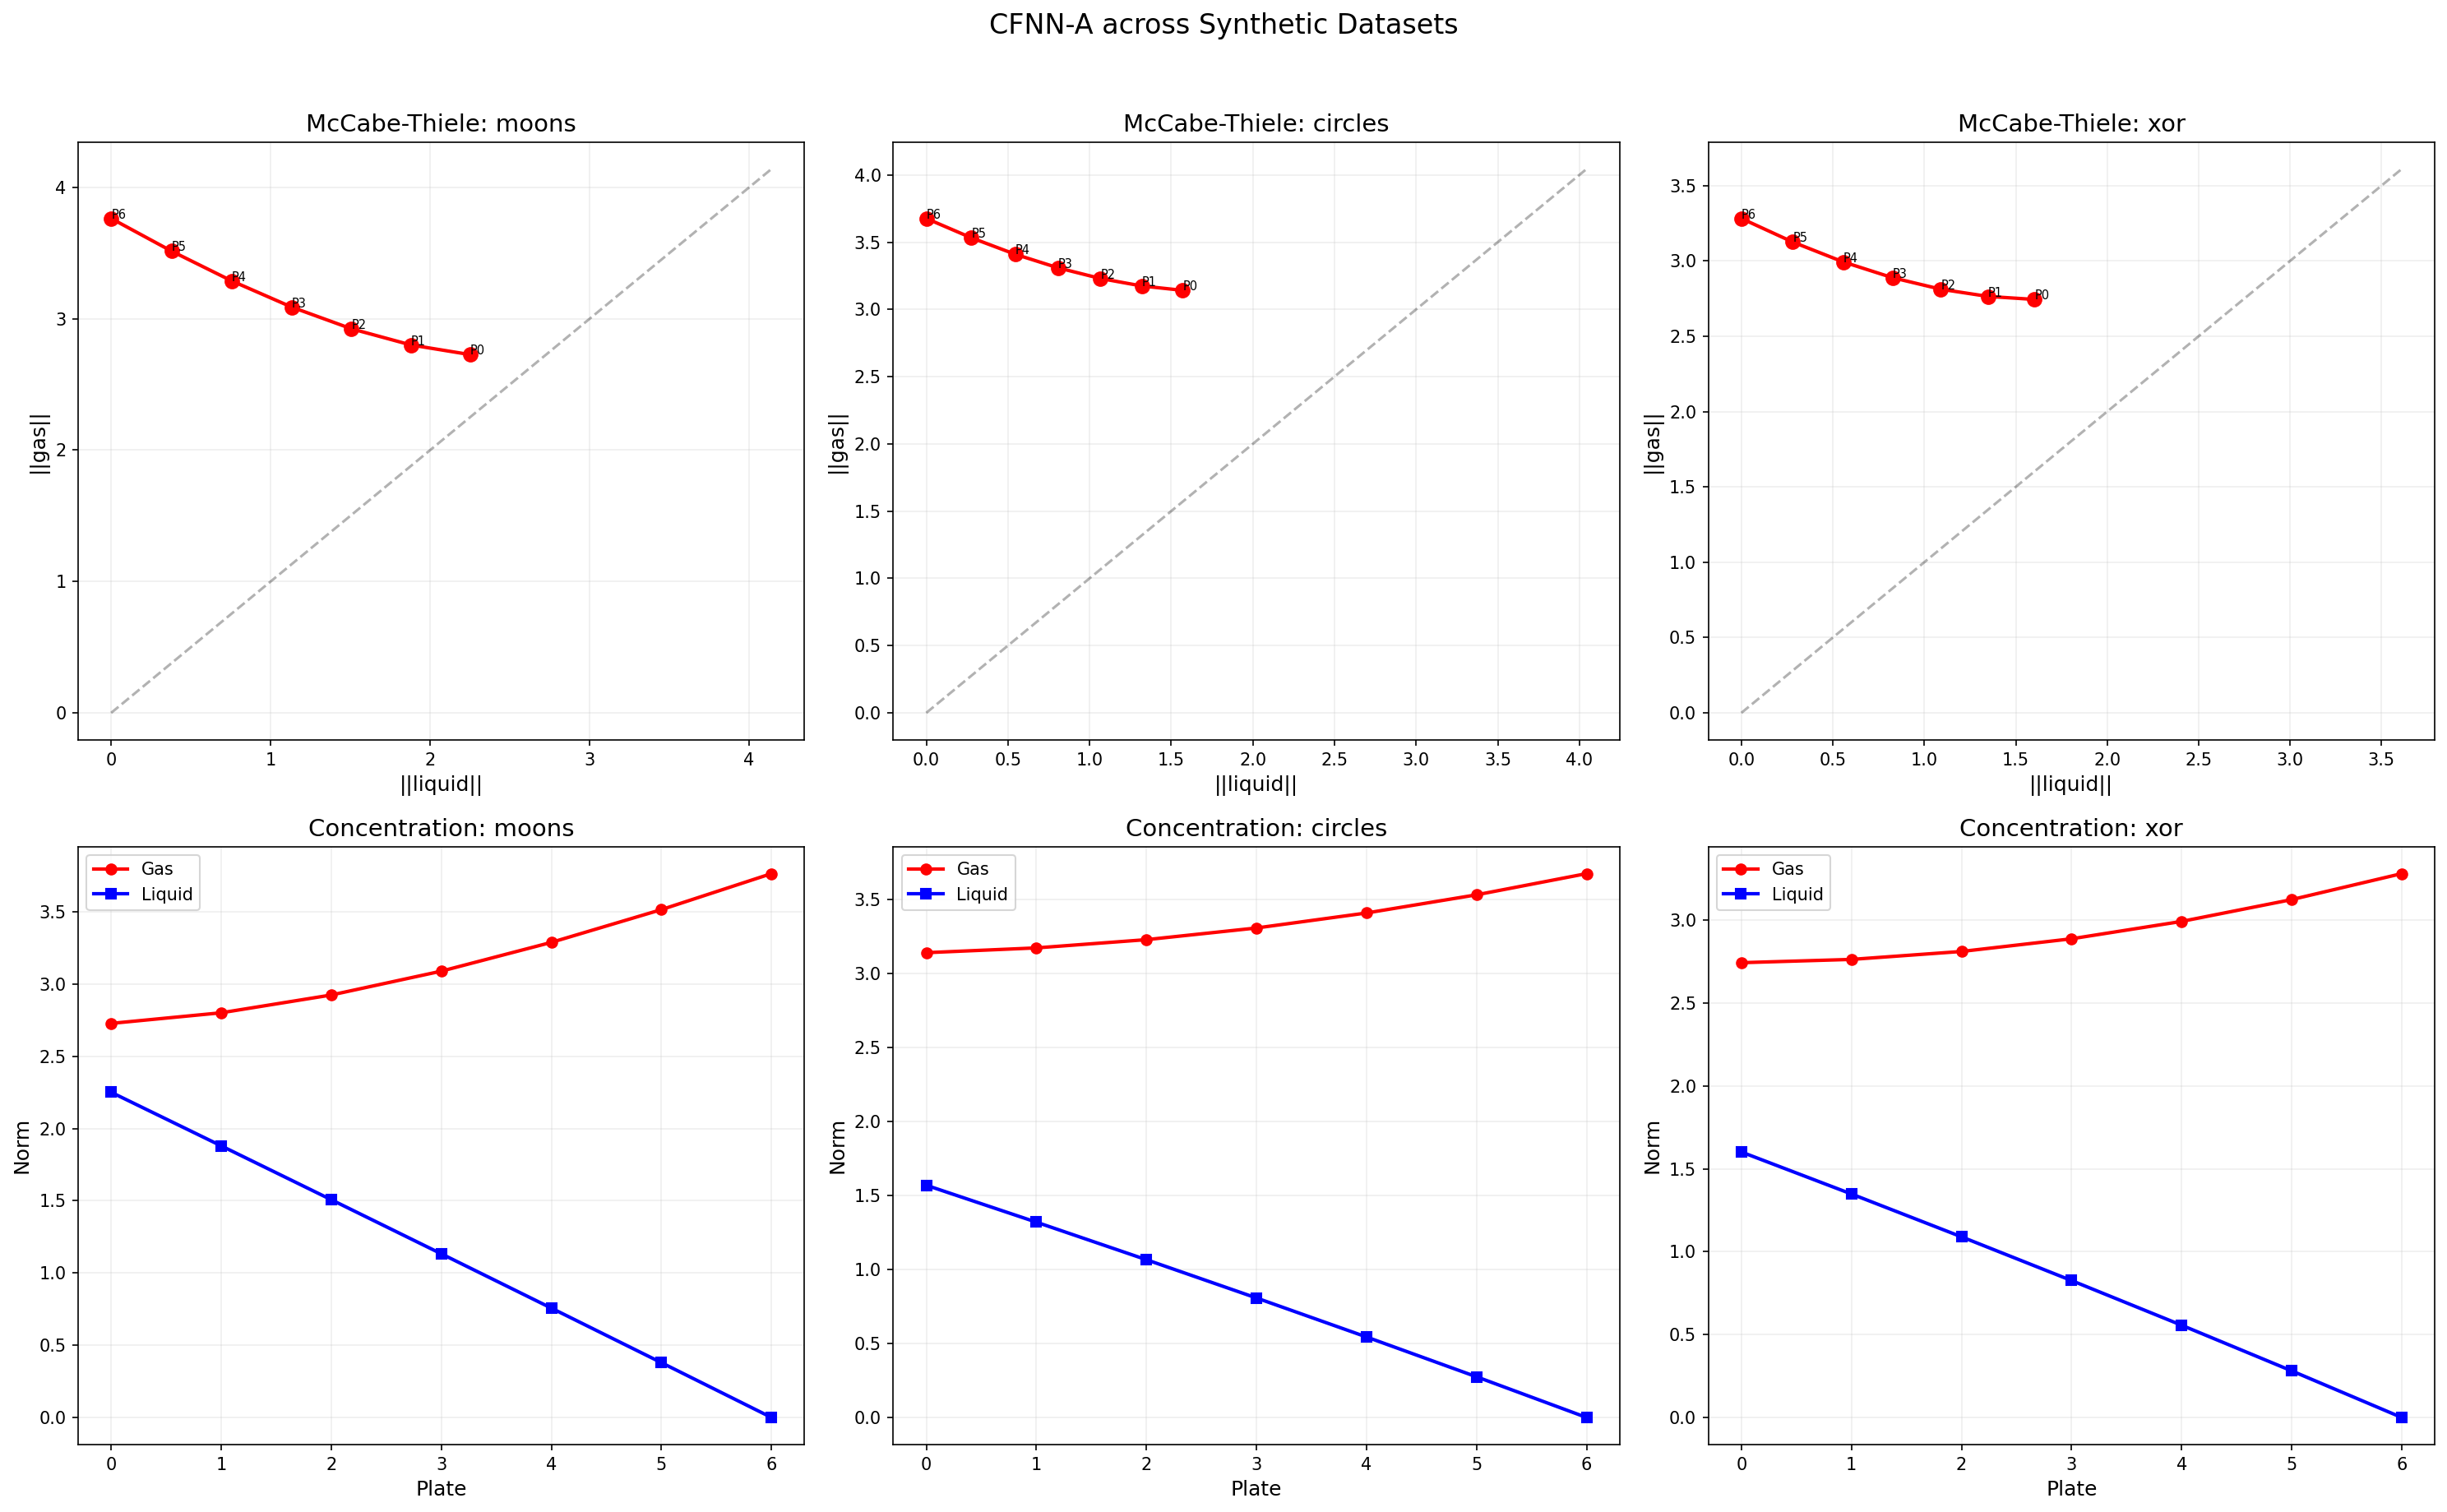

In [12]:
# Train and visualize on all 3 synthetic datasets
datasets = ['moons', 'circles', 'xor']
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

for i, ds in enumerate(datasets):
    X, y = load_synthetic_dataset(ds, n_samples=1000, seed=42)
    tr, te, di, nc = prepare_data(X, y, seed=42)
    Xs = torch.FloatTensor(StandardScaler().fit_transform(X))

    # CFNN-A
    m = CounterFlowNetwork(d_in=di, d_gas=32, d_liquid=32, n_plates=6, d_out=nc)
    train_model(m, tr, te, n_epochs=100, device=device, verbose=False)
    m.to('cpu')
    result = m.forward_with_intermediates(Xs)
    gas_norms = [g.norm(dim=-1).mean().item() for g in result['gas_states']]
    liq_norms = [l.norm(dim=-1).mean().item() for l in result['liquid_states']]

    # McCabe-Thiele
    ml = min(len(gas_norms), len(liq_norms))
    axes[0, i].plot(liq_norms[:ml], gas_norms[:ml], 'ro-', linewidth=2, markersize=8)
    mv = max(max(gas_norms[:ml]), max(liq_norms[:ml])) * 1.1
    axes[0, i].plot([0, mv], [0, mv], 'k--', alpha=0.3)
    for j in range(ml):
        axes[0, i].annotate(f'P{j}', (liq_norms[j], gas_norms[j]), fontsize=7)
    axes[0, i].set_title(f'McCabe-Thiele: {ds}')
    axes[0, i].set_xlabel('||liquid||'); axes[0, i].set_ylabel('||gas||')
    axes[0, i].grid(True, alpha=0.2)

    # Concentration profile
    axes[1, i].plot(range(len(gas_norms)), gas_norms, 'ro-', linewidth=2, label='Gas')
    axes[1, i].plot(range(len(liq_norms)), liq_norms, 'bs-', linewidth=2, label='Liquid')
    axes[1, i].set_title(f'Concentration: {ds}')
    axes[1, i].set_xlabel('Plate'); axes[1, i].set_ylabel('Norm')
    axes[1, i].legend(); axes[1, i].grid(True, alpha=0.2)

plt.suptitle('CFNN-A across Synthetic Datasets', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

---
## Phase 3 Complete!

All visualizations are implemented in `src/visualization.py` and can be imported for any CFNN model.

**Key functions:**
- `mccabe_thiele_plot()` — the signature CFNN diagram
- `concentration_profile()` — feature norms through the tower
- `driving_force_profile()` — driving force and transfer at each plate
- `transfer_heatmap()` — per-dimension exchange patterns
- `diagnostic_dashboard()` — complete 6-panel analysis
- `column_schematic()` — visual tower diagram

**Next steps (Phase 4):**
- Build Gradio Space (`app.py`) with interactive demo
- Deploy to HuggingFace Hub